# Milestone 8 Objective

Build the API Testing Agent as a standalone agent before integrating it into the main LangGraph workflow.

## API Testing Agent Role

The API Agent reads API test cases from `test_plan`, sends HTTP requests to `target_url`, measures duration, evaluates assertions, and writes `api_result.json`.

## Why It Works Alone First

The agent is validated as a standalone executor before it is connected to the main graph, so API execution risks are isolated.

## Mini LangGraph Workflow

```text
START -> api_testing -> END
```

## State Contract

Reads: `target_url`, `test_plan`, `user_preferences`.

Writes: `api_results`, `api_result_path`, `errors`, `agent_logs`.

## Safety Note

The agent does not start the target app. If the app is down, it records `environment_error`. This notebook does not run Django, Docker, Selenium, Locust, MCP, or generated tests.

## Target Repository And URL

- Repository: https://github.com/Vitaee/DjangoRestAPI
- Target URL: http://localhost:8000

## Part A - Offline Unit-Style Execution

In [1]:
import json
import threading
from http.server import BaseHTTPRequestHandler, HTTPServer
from pprint import pprint

from test_auto.agents.api_testing_agent import run_api_testing_agent_alone

class TodoHandler(BaseHTTPRequestHandler):
    def do_GET(self):
        if self.path == "/api/todos/":
            body = json.dumps({"items": ["todo"]}).encode()
            self.send_response(200)
            self.send_header("Content-Type", "application/json")
            self.end_headers()
            self.wfile.write(body)
        else:
            self.send_response(404)
            self.end_headers()

    def do_POST(self):
        if self.path == "/api/todos/":
            body = json.dumps({"created": True}).encode()
            self.send_response(201)
            self.send_header("Content-Type", "application/json")
            self.end_headers()
            self.wfile.write(body)
        else:
            self.send_response(404)
            self.end_headers()

    def log_message(self, format, *args):
        return

server = HTTPServer(("127.0.0.1", 0), TodoHandler)
thread = threading.Thread(target=server.serve_forever, daemon=True)
thread.start()
target_url = f"http://127.0.0.1:{server.server_port}"

test_plan = {
    "api_tests": [
        {"id": "API_001", "name": "list_todos", "method": "GET", "endpoint": "/api/todos/", "expected_status": 200, "assertions": [{"type": "status_code", "expected": "200"}], "evidence_sources": ["todo/urls.py"]},
        {"id": "API_002", "name": "create_todo", "method": "POST", "endpoint": "/api/todos/", "expected_status": 201, "request_body": {"title": "demo"}, "assertions": [{"type": "status_code", "expected": "201"}], "evidence_sources": ["todo/urls.py"]},
        {"id": "API_003", "name": "todo_detail_dynamic", "method": "GET", "endpoint": "/api/todos/<int:pk>/", "expected_status": 200, "evidence_sources": ["todo/urls.py"]},
    ]
}

api_result = run_api_testing_agent_alone(target_url=target_url, test_plan=test_plan)
pprint(api_result["summary"])
pprint(api_result["api_results"]["tests"])
print(api_result["api_result_path"])
server.shutdown()

{'errors': 0,
 'failed': 0,
 'pass_rate': 66.67,
 'passed': 2,
 'skipped': 1,
 'total_tests': 3}
[{'actual_status': 200,
  'assertions': [{'details': 'Expected 200, got 200.',
                  'passed': True,
                  'status': 'passed',
                  'type': 'status_code'},
                 {'details': 'Expected 200, got 200.',
                  'passed': True,
                  'status': 'passed',
                  'type': 'status_code'}],
  'details': 'API test executed successfully.',
  'duration_ms': 14.311999955680221,
  'endpoint': '/api/todos/',
  'error_type': None,
  'evidence': {'method': 'GET',
               'request_body': None,
               'response_json_preview': {'items': '<nested>'},
               'response_preview': '{"items": ["todo"]}',
               'url': 'http://127.0.0.1:58052/api/todos/'},
  'expected_status': 200,
  'id': 'API_001',
  'method': 'GET',
  'name': 'list_todos',
  'status': 'passed'},
 {'actual_status': 201,
  'assertions': [{'

## Part B - Optional Real Target App

This requires the Django target app already running at `http://localhost:8000`. The notebook does not start it.

In [2]:
from pathlib import Path

RUN_REAL_TARGET = False
if RUN_REAL_TARGET:
    candidate_plans = sorted(Path("results/runs").glob("*/test_plan.json")) if Path("results/runs").exists() else []
    if candidate_plans:
        loaded_plan = json.loads(candidate_plans[-1].read_text(encoding="utf-8"))
        real_result = run_api_testing_agent_alone(target_url="http://localhost:8000", test_plan=loaded_plan, run_id=candidate_plans[-1].parent.name)
        pprint(real_result["summary"])
        pprint([item for item in real_result["api_results"]["tests"] if item["status"] != "passed"])
        print(real_result["api_result_path"])
    else:
        print("No previous test_plan.json found.")
else:
    print("Real target run skipped. Set RUN_REAL_TARGET = True only when the target app is already running.")

Real target run skipped. Set RUN_REAL_TARGET = True only when the target app is already running.


## Part C - Mini LangGraph Workflow

In [3]:
from test_auto.graph.api_testing_workflow import run_api_testing_workflow

workflow_state = run_api_testing_workflow({
    "target_url": "http://127.0.0.1:1",
    "test_plan": {"api_tests": [{"id": "API_001", "name": "list_todos", "method": "GET", "endpoint": "/api/todos/", "expected_status": 200}]},
    "errors": [],
    "agent_logs": [],
})
pprint({
    "run_id": workflow_state.get("run_id"),
    "summary": workflow_state.get("api_results", {}).get("summary"),
    "api_result_path": workflow_state.get("api_result_path"),
})

{'api_result_path': 'results\\runs\\run_20260520T084126Z_a9a317b8\\api_result.json',
 'run_id': 'run_20260520T084126Z_a9a317b8',
 'summary': {'errors': 1,
             'failed': 0,
             'pass_rate': 0.0,
             'passed': 0,
             'skipped': 0,
             'total_tests': 1}}


## Part D - Graph Visualization

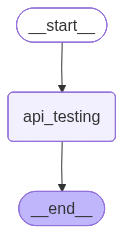

In [4]:
from IPython.display import Image, display
from test_auto.graph.api_testing_workflow import build_api_testing_graph

graph = build_api_testing_graph()
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())